In [7]:
import optuna
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import pandas as pd
from lightgbm import early_stopping, log_evaluation 
from sklearn.model_selection import StratifiedKFold
import numpy as np

读取清洗数据

In [8]:
train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")

In [9]:
train.head()

,label,uid,task_id,adv_id,creat_type_cd,adv_prim_id,dev_id,inter_type_cd,slot_id,spread_app_id,...,list_time,device_price,up_life_duration,up_membership_grade,membership_life_duration,consume_purchase,communication_onlinerate,communication_avgonline_30d,indu_name,pt_d
0,0,2212851,5745,5347,7,122,60,5,21,56,...,7,2,-1,-1,-1,2,6^7^8^9^10^11^12^13^14^15^16^17^18^19^20^21^22^23,9,24,1
1,0,1925055,1181,5315,7,178,17,5,12,70,...,9,3,18,-1,-1,2,4^5^6^7^8^9^10^11^12^13^14^15^16^17^18^19^20^2...,12,36,1
2,0,2015494,1175,4325,3,210,70,4,12,88,...,10,2,18,-1,-1,2,5^6^7^8^9^10^11^12^13^14^15^16^17^18^19^20^21^...,11,27,1
3,0,1191651,3469,5603,7,203,69,5,14,62,...,4,4,20,-1,-1,2,6^7^8^9^10^11^12^13^14^15^16^17^18^19^20^21^22^23,11,16,1
4,1,2074498,5456,2425,7,130,30,5,12,28,...,7,1,-1,-1,-1,2,7^8^9^10^11^12^13^14^15^16^17^18^19^20^21^22^23,10,36,1


In [10]:
test.head()

,uid,task_id,adv_id,creat_type_cd,adv_prim_id,dev_id,inter_type_cd,slot_id,spread_app_id,tags,...,list_time,device_price,up_life_duration,up_membership_grade,membership_life_duration,consume_purchase,communication_onlinerate,communication_avgonline_30d,indu_name,pt_d
0,1387805,5602,6503,7,207,17,5,14,13,37,...,8,4,18,-1,-1,2,6^7^8^9^10^11^12^13^14^15^16^17^18^19^20^21^22^23,11,17,7
1,2065232,1551,5843,7,134,55,4,22,65,18,...,5,4,20,-1,-1,2,7^8^9^10^11^12^13^14^15^16^17^18^19^20^21^22^23,10,14,7
2,2060632,3854,3367,7,207,17,5,17,13,37,...,8,4,-1,-1,-1,2,5^6^7^8^9^10^11^12^13^14^15^16^17^18^19^20^21^...,11,17,7
3,2072738,2205,3989,6,132,60,3,17,78,23,...,4,4,20,1,-1,7,7^8^9^10^11^12^13^14^15^16^17^18^19^20^21^22^23,9,47,7
4,2107165,4189,6509,7,122,18,5,12,56,18,...,10,3,18,-1,-1,2,4^5^6^7^8^9^10^11^12^13^14^15^16^17^18^19^20^2...,12,14,7


In [11]:

print(train.shape)
print(test.shape)
print(train.info())


(9000000, 36)
(500000, 35)
<class 'pandas.DataFrame'>
RangeIndex: 9000000 entries, 0 to 8999999
Data columns (total 36 columns):
 #   Column                       Dtype
---  ------                       -----
 0   label                        int64
 1   uid                          int64
 2   task_id                      int64
 3   adv_id                       int64
 4   creat_type_cd                int64
 5   adv_prim_id                  int64
 6   dev_id                       int64
 7   inter_type_cd                int64
 8   slot_id                      int64
 9   spread_app_id                int64
 10  tags                         int64
 11  app_first_class              int64
 12  app_second_class             int64
 13  age                          int64
 14  city                         int64
 15  city_rank                    int64
 16  device_name                  int64
 17  device_size                  int64
 18  career                       int64
 19  gender                    

In [12]:
# 删除无用列
drop_cols = [
    "uid", "task_id", "adv_id", "dev_id",
    "city", "membership_life_duration", "communication_onlinerate"
]
train = train.drop(columns=drop_cols, errors="ignore")
test  = test.drop(columns=drop_cols, errors="ignore")

In [13]:
def convert_type(df):
    df = df.copy()
    
    for col in df.columns:
        if col == "label":
            continue  # 标签不转
        
        uniq = df[col].nunique()
        
        # 规则：
        # 1. 只有 2 个值（0/1）→ 一定是分类
        # 2. 不超过 10 个值 → 类别特征
        if uniq <= 10:
            df[col] = df[col].astype("category")
    
    return df

train = convert_type(train)
test = convert_type(test)   


In [ ]:
# 查看与 label 相关系数
corr_with_label = train.corr()['label'].sort_values(key=abs, ascending=False)
print("与 label 相关系数：")
print(corr_with_label)

与 label 相关系数（按绝对值排序）：
label                          1.000000
device_price                  -0.047624
app_first_class                0.043731
app_score                      0.043202
his_on_shelf_time              0.041797
slot_id                       -0.038930
adv_prim_id                    0.037114
career                         0.034882
tags                           0.029544
communication_avgonline_30d   -0.027473
indu_name                     -0.025879
inter_type_cd                  0.024976
up_life_duration              -0.023623
city_rank                     -0.022640
emui_dev                      -0.016784
up_membership_grade           -0.014705
net_type                      -0.014403
his_app_size                   0.013964
app_second_class              -0.013793
list_time                      0.012805
spread_app_id                 -0.012177
age                            0.009138
device_size                    0.009022
pt_d                          -0.007191
consume_purchase  

构建新特征
device_city = device_price * city_rank
app_class_score = app_first_class * app_score
online_ratio = communication_avgonline_30d / up_life_duration' + 1
shelf_adv = his_on_shelf_time * adv_prim_id

In [15]:

# 1. 设备价格 × 城市等级（最强组合）
train['device_city'] = train['device_price'].astype(int) * train['city_rank'].astype(int)
test['device_city'] = test['device_price'].astype(int) * test['city_rank'].astype(int)

# 2. APP一级分类 × APP评分（强相关×强相关）
train['app_class_score'] = train['app_first_class'].astype(int) * train['app_score'].astype(int)
test['app_class_score'] = test['app_first_class'].astype(int) * test['app_score'].astype(int)

# 3. 在线时长 / 用户生命周期（活跃度比率）
train['online_ratio'] = train['communication_avgonline_30d'].astype(int) / (train['up_life_duration'].astype(int) + 1)
test['online_ratio'] = test['communication_avgonline_30d'].astype(int) / (test['up_life_duration'].astype(int) + 1)

# 4. 广告上架时间 × 广告主ID（广告侧核心交互）
train['shelf_adv'] = train['his_on_shelf_time'].astype(int) * train['adv_prim_id'].astype(int)
test['shelf_adv'] = test['his_on_shelf_time'].astype(int) * test['adv_prim_id'].astype(int)


# 5. 广告位 × 广告类型（流量坑位 × 创意形式）
train['slot_interact'] = train['slot_id'].astype(int) * train['inter_type_cd'].astype(int)
test['slot_interact'] = test['slot_id'].astype(int) * test['inter_type_cd'].astype(int)

# 6. 职业 × 设备价格（人群购买力）
train['career_device'] = train['career'].astype(int) * train['device_price'].astype(int)
test['career_device'] = test['career'].astype(int) * test['device_price'].astype(int)

# 7. 行业 × 广告主（行业垂直效果）
train['indu_adv'] = train['indu_name'].astype(int) * train['adv_prim_id'].astype(int)
test['indu_adv'] = test['indu_name'].astype(int) * test['adv_prim_id'].astype(int)

# 8. 标签 × APP分类（内容匹配度）
train['tags_app'] = train['tags'].astype(int) * train['app_first_class'].astype(int)
test['tags_app'] = test['tags'].astype(int) * test['app_first_class'].astype(int)

# 9. 设备价格倒数（反向强化负相关）
train['device_price_inv'] = 1 / (train['device_price'].astype(int) + 1e-6)
test['device_price_inv'] = 1 / (test['device_price'].astype(int) + 1e-6)

# 10. 上架时间分箱（新广告/老广告）
train['is_new_ad'] = (train['his_on_shelf_time'].astype(int) <= 30).astype(int)
test['is_new_ad'] = (test['his_on_shelf_time'].astype(int) <= 30).astype(int)

In [ ]:
drop_cols = [
    # 极弱相关
    "age",
    "gender",
    "pt_d",
    "device_size",
    "consume_purchase",
    "creat_type_cd",
    "residence",
    "device_name",
    "app_second_class",   # 被 app_class_score、app_first_class 覆盖
]

train = train.drop(columns=drop_cols)
test = test.drop(columns=drop_cols)

In [ ]:
# 找出所有 category 列
categorical_cols = train.select_dtypes(include=['category']).columns.tolist()

print("类别特征列：")
print(categorical_cols)

类别特征列：
['inter_type_cd', 'app_first_class', 'city_rank', 'career', 'net_type', 'his_on_shelf_time', 'app_score', 'device_price', 'up_membership_grade']


In [18]:
# 训练集
X = train.drop(['label'], axis=1)
y = train['label']

In [19]:
# 测试集
X_test = test.copy()

In [20]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

categorical_cols = X.select_dtypes(include=["category"]).columns.tolist()

In [21]:
# Optuna 目标函数
def objective(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 5, 9),
        "num_leaves": trial.suggest_int("num_leaves", 32, 256),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 100),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),

        "objective": "binary",
        "metric": "auc",
        "random_state": 42,
        "verbosity": -1,
    }

    model = lgb.LGBMClassifier(**params)
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        categorical_feature=categorical_cols,
        callbacks=[early_stopping(50), log_evaluation(0)],
    )

    y_pred_val = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, y_pred_val)

In [22]:
# 启动优化
study = optuna.create_study(direction="maximize", study_name="LGBM_CTR")
study.optimize(objective, n_trials=10)

[I 2026-04-08 11:03:36,492] A new study created in memory with name: LGBM_CTR


Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's auc: 0.69281


[I 2026-04-08 11:04:08,224] Trial 0 finished with value: 0.6928100027303432 and parameters: {'learning_rate': 0.07195474986070666, 'max_depth': 5, 'num_leaves': 46, 'min_child_samples': 28, 'subsample': 0.8274771352416989, 'colsample_bytree': 0.7764348029603438, 'reg_alpha': 3.439546880921954, 'reg_lambda': 0.8298381327475851}. Best is trial 0 with value: 0.6928100027303432.


Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's auc: 0.696542


[I 2026-04-08 11:05:07,785] Trial 1 finished with value: 0.6965417321364302 and parameters: {'learning_rate': 0.047923633245884924, 'max_depth': 9, 'num_leaves': 210, 'min_child_samples': 53, 'subsample': 0.8006482786225829, 'colsample_bytree': 0.746243314730111, 'reg_alpha': 1.1057544734598816, 'reg_lambda': 2.2969636115751295}. Best is trial 1 with value: 0.6965417321364302.


...

[I 2026-04-08 11:09:34,626] Trial 7 finished with value: 0.6924070542107168 and parameters: {'learning_rate': 0.04830830780068182, 'max_depth': 6, 'num_leaves': 79, 'min_child_samples': 92, 'subsample': 0.7409298119244598, 'colsample_bytree': 0.8414218001836651, 'reg_alpha': 0.44657066582084903, 'reg_lambda': 4.809718517622292}. Best is trial 5 with value: 0.6967963067594342.


Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's auc: 0.69776


[I 2026-04-08 11:10:29,293] Trial 8 finished with value: 0.6977604529103067 and parameters: {'learning_rate': 0.09272528577817526, 'max_depth': 9, 'num_leaves': 235, 'min_child_samples': 82, 'subsample': 0.997521982627231, 'colsample_bytree': 0.7891243817561405, 'reg_alpha': 3.539085079197131, 'reg_lambda': 0.31132124944097395}. Best is trial 8 with value: 0.6977604529103067.


Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's auc: 0.692994


[I 2026-04-08 11:11:00,511] Trial 9 finished with value: 0.6929943281450603 and parameters: {'learning_rate': 0.08453561550283857, 'max_depth': 5, 'num_leaves': 66, 'min_child_samples': 80, 'subsample': 0.9621869377141083, 'colsample_bytree': 0.8037808483087021, 'reg_alpha': 3.975563336375373, 'reg_lambda': 0.4983811430301166}. Best is trial 8 with value: 0.6977604529103067.


In [23]:
print("="*50)
print("最佳 AUC:", study.best_value)
print("最优参数:", study.best_params)
print("="*50)

最佳 AUC: 0.6977604529103067
最优参数: {'learning_rate': 0.09272528577817526, 'max_depth': 9, 'num_leaves': 235, 'min_child_samples': 82, 'subsample': 0.997521982627231, 'colsample_bytree': 0.7891243817561405, 'reg_alpha': 3.539085079197131, 'reg_lambda': 0.31132124944097395}


In [ ]:
best_params = {'learning_rate': 0.0711687981939379, 'max_depth': 9, 'num_leaves': 138, 'min_child_samples': 49, 'subsample': 0.8015920334214081, 'colsample_bytree': 0.9650250312251101, 'reg_alpha': 3.1910777724710186, 'reg_lambda': 4.349698597046328}


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))  # 袋外分数
test_preds = np.zeros(len(X_test))  # 测试集预测

# 开始 5折训练
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n========== Fold {fold+1}/5 ==========")
    
    # 划分每折数据
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # 训练
    model = lgb.LGBMClassifier(**best_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        categorical_feature=categorical_cols,
        callbacks=[early_stopping(50), log_evaluation(0)]
    )
    
    # 验证集预测 & 评估
    val_pred = model.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, val_pred)
    print(f"Fold {fold+1} Val AUC: {val_auc:.5f}")
    
    # 累积结果
    oof_preds[val_idx] = val_pred
    test_preds += model.predict_proba(X_test)[:, 1] / 5  # 5折平均


========== Fold 1/5 ==========
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's binary_logloss: 0.140365
Fold 1 Val AUC: 0.69605

========== Fold 2/5 ==========
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's binary_logloss: 0.14016
Fold 2 Val AUC: 0.69865

========== Fold 3/5 ==========
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's binary_logloss: 0.140183
Fold 3 Val AUC: 0.69776

========== Fold 4/5 ==========
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's binary_logloss: 0.140276
Fold 4 Val AUC: 0.69737

========== Fold 5/5 ==========
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's binary_logloss: 0.14

In [35]:
# 输出整体 5折 最终分数
overall_auc = roc_auc_score(y, oof_preds)
print(f"\n OOF AUC: {overall_auc:.5f}")


 OOF AUC: 0.69750


In [34]:
# 使用最优参数训练
sub = pd.DataFrame({
    'id': range(len(test_preds)),
    'label': test_preds
})
sub.to_csv("submission_5fold_final.csv", index=False)

____________________________________________

<Figure size 1200x800 with 0 Axes>

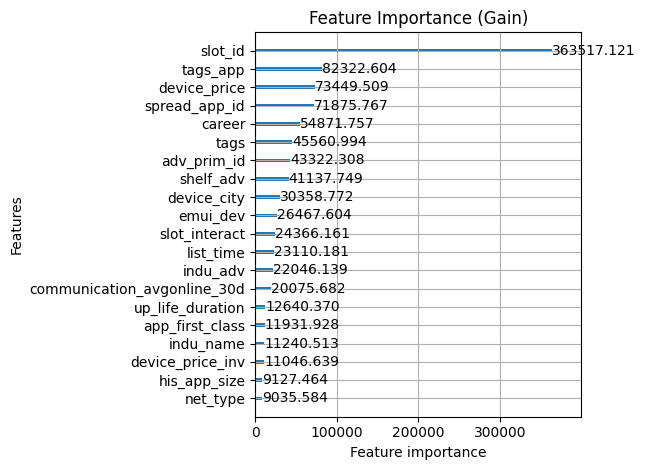

特征重要性 Top 20：
                        feature  gain
2                       slot_id  1094
0                   adv_prim_id  1067
13                    list_time   975
7                        career   848
3                 spread_app_id   837
12                     emui_dev   805
25                     indu_adv   752
22                    shelf_adv   728
21                 online_ratio   687
23                slot_interact   592
17  communication_avgonline_30d   572
19                  device_city   556
24                career_device   488
15             up_life_duration   482
9                  his_app_size   463
4                          tags   447
8                      net_type   415
14                 device_price   385
18                    indu_name   321
26                     tags_app   312


In [38]:
import matplotlib.pyplot as plt
import pandas as pd

# 画出特征重要性图
plt.figure(figsize=(12, 8))
lgb.plot_importance(model, max_num_features=20, importance_type='gain')
plt.title('Feature Importance (Gain)')
plt.tight_layout()
plt.show()

# 输出详细表格
feature_imp = pd.DataFrame({
    'feature': model.feature_name_,
    'gain': model.feature_importances_
}).sort_values('gain', ascending=False)
print("特征重要性 Top 20：")
print(feature_imp.head(20))

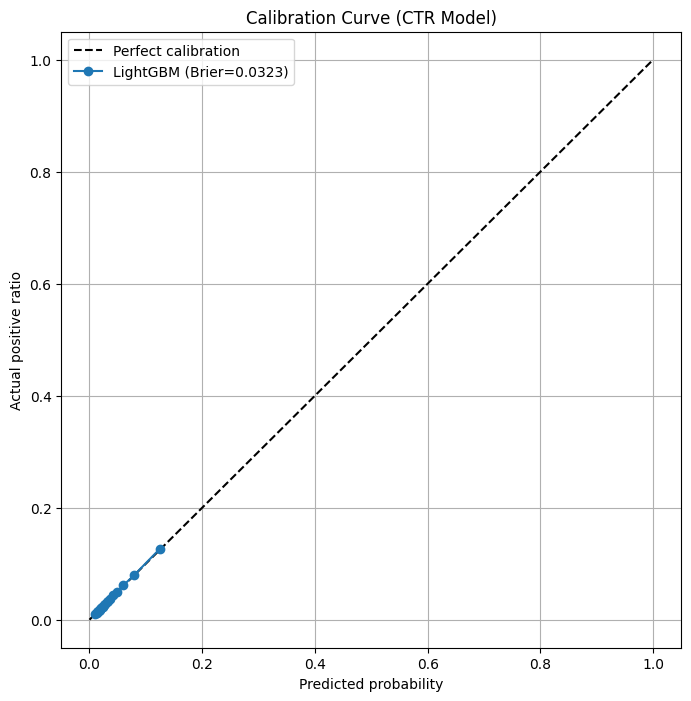

📊 Brier Score: 0.0323
✅ 分数越小 → 概率越准
✅ 曲线越贴近虚线 → 校准越好


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss


# 计算校准曲线
# oof_preds 是5折的袋外预测概率, y 是真实标签
fraction_of_positives, mean_predicted_value = calibration_curve(
    y, oof_preds, n_bins=20, strategy="quantile"
)

# 布里尔分数
brier = brier_score_loss(y, oof_preds)


# 画图
plt.figure(figsize=(8, 8))

# 完美校准线
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")

# 模型校准曲线
plt.plot(
    mean_predicted_value,
    fraction_of_positives,
    "o-",
    label=f"LightGBM (Brier={brier:.4f})"
)

plt.title("Calibration Curve (CTR Model)")
plt.xlabel("Predicted probability")
plt.ylabel("Actual positive ratio")
plt.legend()
plt.grid(True)
plt.show()


# 打印校准结果
print(f"Brier Score: {brier:.4f}")
